# Ερώτημα 1 - Exploratory Data Analysis (CIC-IDS-2017)

**Στόχοι αυτού του notebook**

1. Κατανόηση της πρωτογενούς δομής του dataset (γραμμές, στήλες, τύποι).
2. Καθαρισμός των δεδομένων (missing values, infinities, duplicates) με τεκμηριωμένες αποφάσεις.
3. Μελέτη της κατανομής της μεταβλητής-στόχου και μέτρηση του class imbalance.
4. Στατιστική και οπτική περιγραφή κάθε feature.
5. Εύρεση συσχετίσεων (multicollinearity) μεταξύ των features και με το Label.
6. Εκτέλεση αιτιολογημένου feature selection.
7. Αποθήκευση του καθαρού, feature-selected dataset ως αρχείο Parquet ώστε το Ερώτημα 2 (classification) και το Ερώτημα 3 (clustering) να το ξαναχρησιμοποιήσουν ακαριαία.

> **Σημείωση.** Κάθε κελί κώδικα συνοδεύεται από σύντομο σχολιασμό που εξηγεί *τι* βλέπουμε και *γιατί* έχει σημασία, μαζί με την τεκμηρίωση κάθε απόφασης προεπεξεργασίας.

## 0. Imports και environment setup

In [1]:
import sys
import warnings
from pathlib import Path

# Κάνουμε importable το project root ώστε να δουλεύει το `from utils.helpers import ...`.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Το Pandas 3.x υπολογίζει την Pearson correlation μέσω np.corrcoef, το οποίο
# εκπέμπει ένα ακίνδυνο RuntimeWarning για zero-variance στήλες (0/0 → NaN).
# Σιγάζουμε global αυτό το συγκεκριμένο warning ώστε το output του notebook
# να είναι καθαρό.
warnings.filterwarnings('ignore', category=RuntimeWarning,
                        message='invalid value encountered in divide')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.helpers import (
    RANDOM_STATE,
    load_cic_ids_2017,
    handle_infinities,
    drop_duplicates_report,
    save_figure,
    save_results,
    save_clean_cached,
    top_correlated_pairs,
    find_low_variance_features,
    find_highly_correlated_features,
)

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print('NumPy', np.__version__)
print('Pandas', pd.__version__)
print('Random seed', RANDOM_STATE)


NumPy 2.4.4
Pandas 3.0.2
Random seed 42


**Γιατί αυτά τα imports έχουν σημασία**

- Το κόλπο με το `sys.path`: τα notebooks ζουν στον φάκελο `notebooks/` οπότε η Python δεν βλέπει το αδελφικό πακέτο `utils/` χωρίς βοήθεια.
- Το `RANDOM_STATE = 42` το κάνουμε import από το `utils.helpers` ώστε κάθε notebook να χρησιμοποιεί τον *ίδιο* seed - απαραίτητο για **reproducibility** (αν ξανατρέξουμε το notebook, πρέπει να βγάλουμε τους ίδιους αριθμούς).
- Το `seaborn` είναι wrapper πάνω από το matplotlib που παράγει πιο όμορφα στατιστικά plots με λιγότερο κώδικα.
- Τα `load_cic_ids_2017` / `handle_infinities` / κ.λπ. είναι οι helpers προεπεξεργασίας που σχεδιάσαμε στο Phase 0.

## 1.1 Δομή του dataset

Φορτώνουμε και τα 8 ημερήσια CSV αρχεία και τα συνενώνουμε σε ένα DataFrame. Ο helper χειρίζεται τρεις ιδιαιτερότητες του CIC-IDS-2017 που εντοπίσαμε στο Phase 0:

1. Κάθε όνομα στήλης έχει leading space (bug του CSV writer του CICFlowMeter) - το αφαιρούμε.
2. Η `Fwd Header Length.1` είναι 100% διπλότυπο της `Fwd Header Length` - τη διαγράφουμε.
3. Τα labels επιθέσεων περιέχουν αλλοιωμένο UTF-8 replacement character εκεί που θα έπρεπε να υπάρχει en-dash - κάνουμε normalize σε καθαρό ASCII.

Αναμενόμενο αποτέλεσμα: ~2.83M γραμμές × 79 στήλες, ~1 GB RAM.  
Η πρώτη φόρτωση από τα raw CSVs παίρνει ~60 δευτερόλεπτα. Οι επόμενες εκτελέσεις σε Q2/Q3 διαβάζουν το cached Parquet σε ένα-δύο δευτερόλεπτα.

In [2]:
df = load_cic_ids_2017()
print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
mem_gb = df.memory_usage(deep=True).sum() / 1e9
print(f'Memory : {mem_gb:.2f} GB (in-RAM after downcasting)')


Shape  : 2,830,743 rows × 79 columns
Memory : 1.04 GB (in-RAM after downcasting)


In [3]:
df.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,__source_file
0,54865,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,110091.7431,18348.6238,109.0000,0.0000,109,109,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,9174.3119,9174.3119,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,230769.2308,38461.5385,52.0000,0.0000,52,52,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,19230.7692,19230.7692,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,352941.1765,58823.5294,34.0000,0.0000,34,34,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,29411.7647,29411.7647,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [4]:
df.tail()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,__source_file
2830738,53,32215,4,2,112,152,28,28,28.0000,0.0000,76,76,76.0000,0.0000,8194.9402,186.2486,6443.0000,13617.5795,30780,3,30832,10277.3333,17755.8438,30780,4,3,3.0000,0.0000,3,3,0,0,0,0,80,64,124.1658,62.0829,28,76,41.7143,23.4216,548.5714,0,0,0,0,0,0,0,0,0,48.6667,28.0000,76.0000,0,0,0,0,0,0,4,112,2,152,-1,-1,3,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2830739,53,324,2,2,84,362,42,42,42.0000,0.0000,181,181,181.0000,0.0000,1376543.2100,12345.6790,108.0000,183.5974,320,2,2,2.0000,0.0000,2,2,2,2.0000,0.0000,2,2,0,0,0,0,40,40,6172.8395,6172.8395,42,181,97.6000,76.1334,5796.3000,0,0,0,0,0,0,0,0,1,122.0000,42.0000,181.0000,0,0,0,0,0,0,2,84,2,362,-1,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2830740,58030,82,2,1,31,6,31,0,15.5000,21.9203,6,6,6.0000,0.0000,451219.5122,36585.3659,41.0000,52.3259,78,4,4,4.0000,0.0000,4,4,0,0.0000,0.0000,0,0,1,0,0,0,64,20,24390.2439,12195.1220,0,31,17.0000,16.3503,267.3333,0,1,0,0,1,0,0,0,0,22.6667,15.5000,6.0000,0,0,0,0,0,0,2,31,1,6,1006,0,0,32,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2830741,53,1048635,6,2,192,256,32,32,32.0000,0.0000,128,128,128.0000,0.0000,427.2221,7.6290,149805.0000,375521.0405,1000947,1,1033613,206722.6000,444210.0686,1000947,1,3,3.0000,0.0000,3,3,0,0,0,0,120,40,5.7217,1.9072,32,128,53.3333,42.3320,1792.0000,0,0,0,0,0,0,0,0,0,60.0000,32.0000,128.0000,0,0,0,0,0,0,6,192,2,256,-1,-1,5,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2830742,53,94939,4,2,188,226,47,47,47.0000,0.0000,113,113,113.0000,0.0000,4360.6948,63.1985,18987.8000,31664.1026,73049,1,73051,24350.3333,42174.2825,73049,1,48,48.0000,0.0000,48,48,0,0,0,0,104,64,42.1323,21.0662,47,113,65.8571,32.2047,1037.1429,0,0,0,0,0,0,0,0,0,76.8333,47.0000,113.0000,0,0,0,0,0,0,4,188,2,226,-1,-1,3,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv


### Σύνοψη τύπων δεδομένων

Μετά τη βελτιστοποίηση μνήμης, οι περισσότερες στήλες είναι `int8`/`int16`/`int32`· μερικές γίνονται `float32` ή παραμένουν `float64` (γιατί τιμές Inf/NaN εμποδίζουν το down-casting σε μικρότερους float τύπους). Οι στήλες `Label` και `__source_file` είναι object strings.

In [5]:
df.dtypes.value_counts()


int32      27
int8       18
float64    15
float32     9
int16       7
str         2
int64       1
Name: count, dtype: int64

In [6]:
# Συμπυκνωμένος κατάλογος ανά στήλη: όνομα, dtype, # non-null, # unique.
def column_catalogue(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        'dtype'   : df.dtypes.astype(str),
        'non_null': df.count(),
        'n_unique': df.nunique(dropna=True),
    })
    out.index.name = 'column'
    return out

catalogue = column_catalogue(df)
save_results(catalogue.reset_index(), 'q1_column_catalogue.csv')
catalogue


,dtype,non_null,n_unique
column,,,
Destination Port,int32,2830743,53805
Flow Duration,int32,2830743,1050899
Total Fwd Packets,int32,2830743,1432
Total Backward Packets,int32,2830743,1747
Total Length of Fwd Packets,int32,2830743,17928
...,...,...,...
Idle Std,float64,2830743,197616
Idle Max,int32,2830743,149737
Idle Min,int32,2830743,223888


### Τι αντιπροσωπεύουν αυτά τα network-traffic features;

Το dataset παράχθηκε από το [CICFlowMeter](https://www.unb.ca/cic/research/applications.html#CICFlowMeter), το οποίο μετατρέπει raw pcap traffic σε **bidirectional network flows**. Ένα flow είναι το σύνολο των πακέτων που μοιράζονται το ίδιο (src IP, dst IP, src port, dst port, protocol) εντός ενός timeout. Για κάθε flow το CICFlowMeter παράγει ~80 στατιστικά features.

Οι ~78 αριθμητικές στήλες ανήκουν σε λίγες σημασιολογικές ομάδες:

| Ομάδα | Παράδειγμα στηλών | Τι περιγράφει |
|---|---|---|
| **Flow identity / duration** | `Destination Port`, `Flow Duration` | ποια υπηρεσία, πόσο διήρκεσε το flow (μs) |
| **Packet counts** | `Total Fwd Packets`, `Total Backward Packets` | όγκος σε κάθε κατεύθυνση |
| **Byte counts** | `Total Length of Fwd Packets`, `Fwd/Bwd Packet Length {Max,Min,Mean,Std}` | κατανομή μεγέθους payload |
| **Rates** | `Flow Bytes/s`, `Flow Packets/s`, `Fwd/Bwd Packets/s` | throughput - *επιρρεπή σε Inf* όταν duration = 0 μs |
| **Inter-arrival times (IAT)** | `Flow IAT {Mean,Std,Max,Min}`, `Fwd/Bwd IAT {...}` | απόσταση μεταξύ πακέτων - κοντινά/κανονικά IATs είναι σήμα scripted traffic (DoS, scans) |
| **TCP flag counts** | `FIN`, `SYN`, `RST`, `PSH`, `ACK`, `URG`, `CWE`, `ECE` Flag Counts | παρουσία κάθε TCP control flag στο flow |
| **Header / segment sizes** | `Fwd Header Length`, `Bwd Header Length`, `Avg {Fwd,Bwd} Segment Size` | TCP/IP overhead και τυπικό segment size |
| **Bulk transfer** | `Fwd/Bwd Avg Bytes/Bulk`, `.../Packets/Bulk`, `.../Bulk Rate` | συμπεριφορά σε bulk phases (σχεδόν πάντα μηδέν σε αυτό το dataset) |
| **Subflow stats** | `Subflow Fwd Packets`, `Subflow Bwd Packets` κ.λπ. | στατιστικά μέσα σε subflow windows |
| **Initial window** | `Init_Win_bytes_forward`, `Init_Win_bytes_backward` | TCP initial receive window που ανακοίνωσε κάθε πλευρά |
| **Activity / idle** | `Active {Mean,Std,Max,Min}`, `Idle {...}` | bursty vs. idle περίοδοι μέσα στο flow |
| **Target** | `Label` | `BENIGN` ή ο τύπος επίθεσης |

**Γιατί οι επιθέσεις εμφανίζονται εδώ.** Οι επιθέσεις έχουν *δομικές υπογραφές* ορατές σε αυτούς τους αριθμούς:
- Τα **port scans** παράγουν πολλά μικροσκοπικά flows 1-2 πακέτων σε διαδοχικά destination ports.
- Τα **DoS / DDoS** παράγουν υψηλά packet rates, μικρά IATs, και καταιγίδες SYN χωρίς αντίστοιχα ACK.
- Το **Brute-force / Patator** δείχνει κανονικά χρονικά μοτίβα (scripted) σε service ports (FTP 21, SSH 22).
- Το **Heartbleed** έχει χαρακτηριστικά μεγέθη payload και συγκεκριμένα TLS record bytes.

Γι' αυτό τα network-flow features - όχι τα raw packet bytes - επαρκούν για να ανιχνεύσουμε τις περισσότερες επιθέσεις στατιστικά.

## 1.2 Missing values, infinities και duplicates

Πριν από οποιαδήποτε μοντελοποίηση χρειαζόμαστε ένα καθαρό frame. Τρία πράγματα μπορούν να το «μολύνουν»:

1. **NaN** - πραγματικά missing values.
2. **±Inf** - εμφανίζονται σε rate στήλες επειδή `Flow Bytes/s = bytes / duration_us`· όταν η διάρκεια είναι 0 μs (flow με ένα πακέτο), η διαίρεση εκρήγνυται. Οποιοσδήποτε `StandardScaler` ή distance-based model θα σπάσει με Inf.
3. **Διπλότυπες γραμμές** - το CICFlowMeter περιστασιακά εκπέμπει το ίδιο flow δύο φορές, και η συνένωση 8 ημερήσιων αρχείων μπορεί να εισάγει διαφυλικά duplicates.

### Βήμα 1 - μέτρηση infinities *πριν* τη μετατροπή

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns
inf_mask = np.isinf(df[numeric_cols])
inf_per_col = inf_mask.sum()
inf_total = int(inf_mask.values.sum())
print(f'Total infinite values in the frame: {inf_total:,}')
print('Columns containing Infs:')
inf_per_col[inf_per_col > 0].sort_values(ascending=False)


Total infinite values in the frame: 4,376
Columns containing Infs:


Flow Packets/s    2867
Flow Bytes/s      1509
dtype: int64

Τα Inf ζουν σχεδόν αποκλειστικά στα `Flow Bytes/s` και `Flow Packets/s` - ακριβώς στις rate στήλες που προβλέψαμε. Τα αντικαθιστούμε με `NaN` ώστε να τα χειριστούμε ομοιόμορφα με τα υπόλοιπα missing values.

In [8]:
df = handle_infinities(df)
remaining_inf = int(np.isinf(df[numeric_cols]).values.sum())
print(f'Infs after handling: {remaining_inf}')


Infs after handling: 0


### Βήμα 2 - μέτρηση missing values (τώρα συμπεριλαμβάνοντας τα πρώην Infs)

In [9]:
na_count = df.isna().sum()
na_pct = (na_count / len(df) * 100).round(4)
na_report = pd.DataFrame({'na_count': na_count, 'na_pct': na_pct})
na_report = na_report[na_report['na_count'] > 0].sort_values('na_count', ascending=False)
print(f'Columns with NaN: {len(na_report)} / {df.shape[1]}')
print(f'Total rows containing any NaN: {df.isna().any(axis=1).sum():,} ({df.isna().any(axis=1).mean()*100:.3f}%)')
na_report


Columns with NaN: 2 / 79


Total rows containing any NaN: 2,867 (0.101%)


,na_count,na_pct
Flow Bytes/s,2867,0.1013
Flow Packets/s,2867,0.1013


**Απόφαση - διαγραφή των affected γραμμών.** Οι επηρεαζόμενες γραμμές είναι <0.1% του dataset, συγκεντρωμένες σε δύο rate στήλες. Εξετάζουμε τις εναλλακτικές:

| Επιλογή | Πλεονεκτήματα | Μειονεκτήματα | Απόφαση |
|---|---|---|---|
| **Drop rows** | απλό, διατηρεί την κατανομή | χάνει δεδομένα | μικρό ποσοστό, ασφαλές |
| Imputation με median | κρατά κάθε γραμμή | κατασκευάζει τιμές, εισάγει bias στις rate στήλες | επικίνδυνο: το NaN προκύπτει από μηδενική duration - η γραμμή ήταν ήδη ανώμαλη |
| Imputation με 0 | απλό | δηλώνει «μηδενικό throughput» - πραγματολογικά λάθος | όχι |

Η διαγραφή του 0.1% των γραμμών δεν μας κοστίζει τίποτα· το imputation θα εισήγαγε θόρυβο σε στήλες που θα τροφοδοτήσουν τον classifier.

In [10]:
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Rows before: {before:,}')
print(f'Rows after : {len(df):,}  (dropped {before-len(df):,}, {(before-len(df))/before*100:.3f}%)')


Rows before: 2,830,743
Rows after : 2,827,876  (dropped 2,867, 0.101%)


### Βήμα 3 - διαγραφή ακριβών διπλότυπων γραμμών

In [11]:
df, n_dup = drop_duplicates_report(df)
print(f'Duplicate rows removed: {n_dup:,}')
print(f'Remaining rows        : {len(df):,}')


Duplicate rows removed: 255,236
Remaining rows        : 2,572,640


**Γιατί τα duplicates έχουν σημασία για το ML.**
Τα ακριβή duplicates φουσκώνουν όποια κλάση τα περιέχει. Αν λίγες χιλιάδες BENIGN γραμμές επαναλαμβάνονται, τα accuracy scores μας φαίνονται τεχνητά υψηλότερα. Πιο λεπτό: μπορούν να «διαρρεύσουν» ανάμεσα σε train/test split (ίδια γραμμή και στα δύο) και να φουσκώσουν τις metrics validation. Η αφαίρεση duplicates *πριν* το split είναι καθιερωμένη άμυνα.

## 1.3 Στατιστική περιγραφή

Για κάθε αριθμητική στήλη θέλουμε mean, std, min, quartiles, max, και δύο δείκτες σχήματος:

- **Skewness** - ασυμμετρία. 0 = συμμετρικό, >0 = μακριά δεξιά ουρά, <0 = μακριά αριστερή ουρά.
- **Kurtosis** - «βαρύτητα» ουρών. 0 (Fisher-normalized) = κανονική, >0 = παχύτερες ουρές / περισσότεροι outliers, <0 = λεπτότερες ουρές.

Οι περισσότερες στήλες του CIC-IDS-2017 έχουν τεράστιο θετικό skewness και kurtosis - τα flow counts και byte counts εκτείνονται σε πολλές τάξεις μεγέθους. Αυτό είναι προειδοποίηση ότι πολλά plots θα χρειαστούν log scale.

In [12]:
numeric_df = df.select_dtypes(include=np.number)
desc = numeric_df.describe(percentiles=[.25, .5, .75]).T
desc['skew'] = numeric_df.skew()
desc['kurt'] = numeric_df.kurt()
desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurt']]
save_results(desc.reset_index().rename(columns={'index': 'feature'}), 'q1_describe.csv')
print(f'Saved full stats table to outputs/results/q1_describe.csv ({desc.shape[0]} features)')
desc.head(15)


Saved full stats table to outputs/results/q1_describe.csv (77 features)


,count,mean,std,min,25%,50%,75%,max,skew,kurt
Destination Port,2572640.0000,8522.8968,18863.4508,0.0000,53.0000,80.0000,443.0000,65535.0000,1.9659,2.0600
Flow Duration,2572640.0000,16257359.7650,34953760.7696,-13.0000,200.0000,48854.0000,5225583.2500,119999998.0000,1.9974,2.3415
Total Fwd Packets,2572640.0000,10.1160,786.3759,1.0000,2.0000,2.0000,5.0000,219759.0000,232.9739,56123.7616
Total Backward Packets,2572640.0000,11.3703,1046.2197,0.0000,1.0000,2.0000,5.0000,291922.0000,233.2588,56363.2161
Total Length of Fwd Packets,2572640.0000,601.3675,10481.3719,0.0000,12.0000,66.0000,325.0000,12900000.0000,768.2927,898932.8890
Total Length of Bwd Packets,2572640.0000,17781.1404,2373892.5879,0.0000,6.0000,152.0000,860.0000,655453030.0000,232.9256,55984.5759
Fwd Packet Length Max,2572640.0000,227.2603,749.2406,0.0000,6.0000,40.0000,201.0000,24820.0000,9.4271,125.0956
Fwd Packet Length Min,2572640.0000,19.4929,60.3800,0.0000,0.0000,6.0000,37.0000,2325.0000,19.3868,438.1369
Fwd Packet Length Mean,2572640.0000,62.9087,193.6676,0.0000,6.0000,36.0000,52.0000,5940.8569,8.7708,87.2744
Fwd Packet Length Std,2572640.0000,75.7751,294.0742,0.0000,0.0000,0.0000,71.6719,7125.5967,10.0612,127.5377


In [13]:
print('Top-10 most right-skewed features:')
desc.sort_values('skew', ascending=False)[['mean', 'std', 'min', 'max', 'skew', 'kurt']].head(10)


Top-10 most right-skewed features:


,mean,std,min,max,skew,kurt
Total Length of Fwd Packets,601.3675,10481.3719,0.0000,12900000.0000,768.2927,898932.8890
Subflow Fwd Bytes,601.3560,10467.1889,0.0000,12870338.0000,766.4129,895596.8931
act_data_pkt_fwd,5.9088,667.5857,0.0000,213557.0000,271.3111,75501.7627
Total Backward Packets,11.3703,1046.2197,0.0000,291922.0000,233.2588,56363.2161
Subflow Bwd Packets,11.3703,1046.2197,0.0000,291922.0000,233.2588,56363.2161
Subflow Fwd Packets,10.1160,786.3759,1.0000,219759.0000,232.9739,56123.7616
Total Fwd Packets,10.1160,786.3759,1.0000,219759.0000,232.9739,56123.7616
Subflow Bwd Bytes,17780.7662,2373860.3133,0.0000,655453030.0000,232.9298,55986.8951
Total Length of Bwd Packets,17781.1404,2373892.5879,0.0000,655453030.0000,232.9256,55984.5759
Fwd URG Flags,0.0000,0.0056,0.0000,1.0000,179.3183,32153.0625


Αρκετές στήλες έχουν skewness > 100 και kurtosis στις *χιλιάδες*. Αυτό σημαίνει ότι ένα μικρό σύνολο flows έχει byte counts ή διαρκειες εκατομμύρια φορές μεγαλύτερες από το median - DDoS amplification και μακροχρόνιες Hulk επιθέσεις. Το λαμβάνουμε υπόψη όταν κάνουμε plot (τα boxplots σε linear scale θα είναι δυσανάγνωστα) και όταν θα κάνουμε scaling στο Q2 (ο `StandardScaler` υποθέτει σχεδόν καμπανοειδή κατανομή· ίσως εξετάσουμε `RobustScaler` για τις πιο ακραίες στήλες).

## 1.4 Μεταβλητή-στόχος `Label` - κατανομή & imbalance

Η στήλη-στόχος μας λέει αν κάθε flow είναι benign ή σε ποιά κλάση επίθεσης ανήκει. Το intrusion detection είναι εξόχως ανισόρροπο: στην πραγματικότητα η μεγάλη πλειοψηφία του traffic είναι benign. Πρέπει να **μετρήσουμε** αυτή την ανισορροπία πριν σχεδιάσουμε το Q2.

In [14]:
label_counts = df['Label'].value_counts()
label_pct = (label_counts / len(df) * 100).round(4)
label_table = pd.DataFrame({'count': label_counts, 'pct': label_pct})
save_results(label_table.reset_index().rename(columns={'index': 'label'}), 'q1_label_distribution.csv')
label_table


,count,pct
Label,,
BENIGN,2146899,83.4512
DoS Hulk,172846,6.7186
DDoS,128014,4.9760
PortScan,90694,3.5253
DoS GoldenEye,10286,0.3998
FTP-Patator,5931,0.2305
DoS slowloris,5385,0.2093
DoS Slowhttptest,5228,0.2032
SSH-Patator,3219,0.1251


In [15]:
imbalance_ratio = label_counts.iloc[0] / label_counts.iloc[-1]
print(f'Number of distinct classes : {len(label_counts)}')
print(f'Majority class (BENIGN)    : {label_counts.iloc[0]:,} ({label_pct.iloc[0]}%)')
print(f'Smallest class ({label_counts.index[-1]}) : {label_counts.iloc[-1]:,} ({label_pct.iloc[-1]}%)')
print(f'Imbalance ratio (max/min)  : {imbalance_ratio:,.0f}×')

binary = df['Label'].eq('BENIGN').map({True: 'BENIGN', False: 'ATTACK'}).value_counts()
print('\nBinary view (BENIGN vs ATTACK):')
print(binary)
print(f'Attack share: {(1 - binary["BENIGN"]/binary.sum())*100:.2f}%')


Number of distinct classes : 15
Majority class (BENIGN)    : 2,146,899 (83.4512%)
Smallest class (Heartbleed) : 11 (0.0004%)
Imbalance ratio (max/min)  : 195,173×



Binary view (BENIGN vs ATTACK):
Label
BENIGN    2146899
ATTACK     425741
Name: count, dtype: int64
Attack share: 16.55%


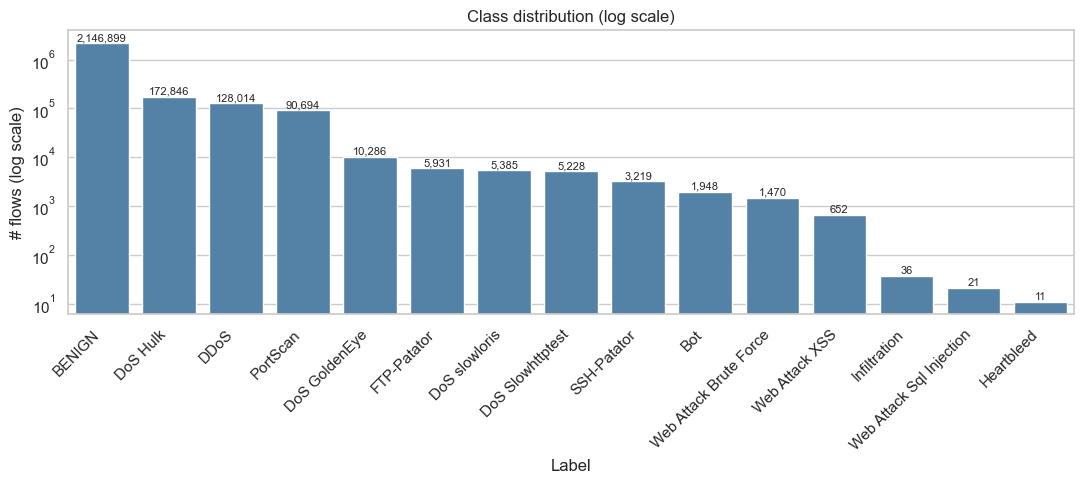

In [16]:
# Bar chart - log scale, αλλιώς οι μικροσκοπικές κλάσεις είναι αόρατες.
fig, ax = plt.subplots(figsize=(11, 5))
order = label_counts.index
sns.barplot(x=order, y=label_counts.values, ax=ax, color='steelblue')
ax.set_yscale('log')
ax.set_xlabel('Label')
ax.set_ylabel('# flows (log scale)')
ax.set_title('Class distribution (log scale)')
ax.tick_params(axis='x', rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_horizontalalignment('right')
for i, v in enumerate(label_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
save_figure(fig, 'q1_label_distribution_bar.png')
plt.show()


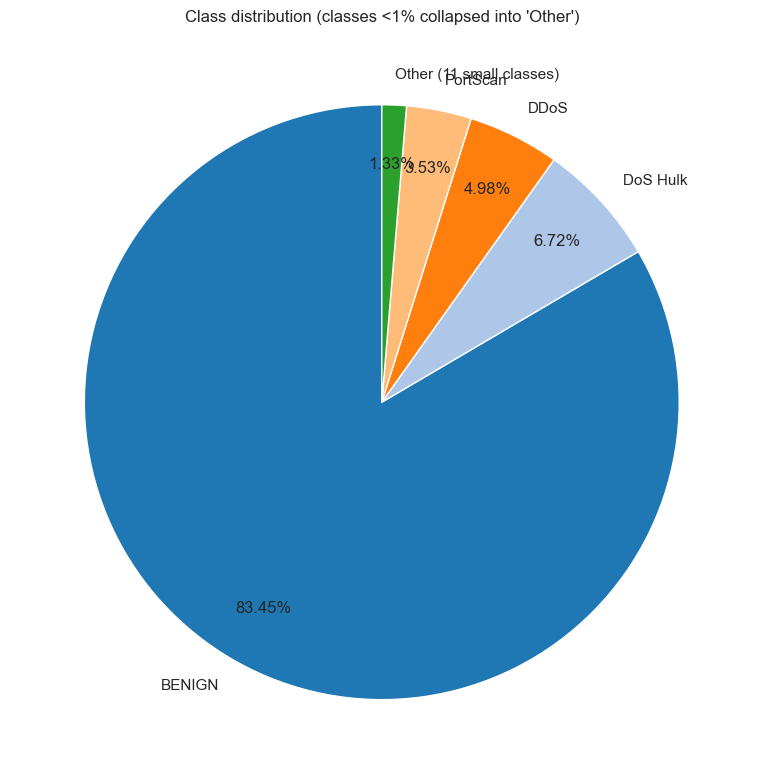

In [17]:
# Pie chart - ενοποίηση των μικροσκοπικών κλάσεων για να είναι αναγνώσιμο.
pie_counts = label_counts.copy()
small = pie_counts[pie_counts / pie_counts.sum() < 0.01]
if len(small) > 0:
    pie_counts = pie_counts.drop(small.index)
    pie_counts['Other (' + str(len(small)) + ' small classes)'] = small.sum()

fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette('tab20', n_colors=len(pie_counts))
wedges, texts, autotexts = ax.pie(
    pie_counts.values, labels=pie_counts.index, autopct='%1.2f%%',
    startangle=90, colors=colors, pctdistance=0.8,
)
ax.set_title('Class distribution (classes <1% collapsed into \'Other\')')
plt.tight_layout()
save_figure(fig, 'q1_label_distribution_pie.png')
plt.show()


### Γιατί το class imbalance είναι *ιδιαίτερα* σοβαρό πρόβλημα στο cybersecurity

Τρεις συνέπειες της ανισορροπίας που μόλις μετρήσαμε:

1. **Το accuracy γίνεται παραπλανητικό.** Ένα τετριμμένο μοντέλο που πάντα προβλέπει `BENIGN` πετυχαίνει ~80% accuracy στο πλήρες dataset - και ~99.9996% accuracy στο Heartbleed subset. Το accuracy κρύβει το γεγονός ότι πιάνει μηδέν επιθέσεις.
   → πρέπει να αναφέρουμε **precision / recall / F1 per class** και ιδίως **macro-F1** (ανεπιστάλης μέσος όρος όλων των κλάσεων).

2. **Οι αλγόριθμοι εκπαίδευσης ελαχιστοποιούν το ολικό loss** by default, που σημαίνει ότι θα αγνοήσουν ευχαρίστως μια κλάση 11 γραμμών για να πιάσουν την majority class.
   → θα χρησιμοποιήσουμε `class_weight='balanced'` στο Q2 (αυξάνει τη συνεισφορά στο loss των σπάνιων κλάσεων) ή **resampling** (SMOTE / undersampling) ως εναλλακτικές.

3. **Η πραγματική ασφάλεια είναι το αντίστροφο αυτού του dataset.** Σε παραγωγή μόνο ~0.001% του traffic είναι κακόβουλο, οπότε ακόμη κι ένα μοντέλο καλό εδώ μπορεί να παράγει πλημμύρα από false positives στο deployment. Γι' αυτό το **false positive rate** είναι συχνά σημαντικότερη metric από το accuracy στην έρευνα IDS.

Το **stratified splitting** (διατηρώντας τις ίδιες class proportions σε train/val/test) είναι υποχρεωτικό εδώ - ένα τυχαίο split θα μπορούσε να βάλει και τις 11 Heartbleed γραμμές στο training set και να αφήσει το test set αδύνατο να αξιολογήσει αυτή την κλάση.

## 1.5 Οπτικοποίηση κατανομών

Το plotting ~78 features σε 2.8M γραμμές θα πάρει αιώνες και θα παράγει δυσανάγνωστο output. Δύο πραγματιστικές απλοποιήσεις:

- Επιλέγουμε ένα **αντιπροσωπευτικό subset** features που καλύπτουν κάθε σημασιολογική ομάδα από την §1.1.
- Υπολογίζουμε τα plots σε **50 000-row stratified sample** - οπτικά δεν διακρίνεται από τα full data σε αυτή την κλίμακα, αλλά 50× γρηγορότερο στο render.

Χρησιμοποιούμε επίσης log-scaled x-axes για τις heavy-tailed στήλες (αλλιώς θα ήταν μία μονή κορυφή κοντά στο μηδέν).

In [18]:
sample_size = 50_000
sample_df = (
    df.groupby('Label', group_keys=False)
      .apply(lambda g: g.sample(min(len(g), max(50, int(sample_size * len(g) / len(df)))), random_state=RANDOM_STATE))
      .reset_index(drop=True)
)
print(f'Stratified sample size: {len(sample_df):,}')


Stratified sample size: 50,132


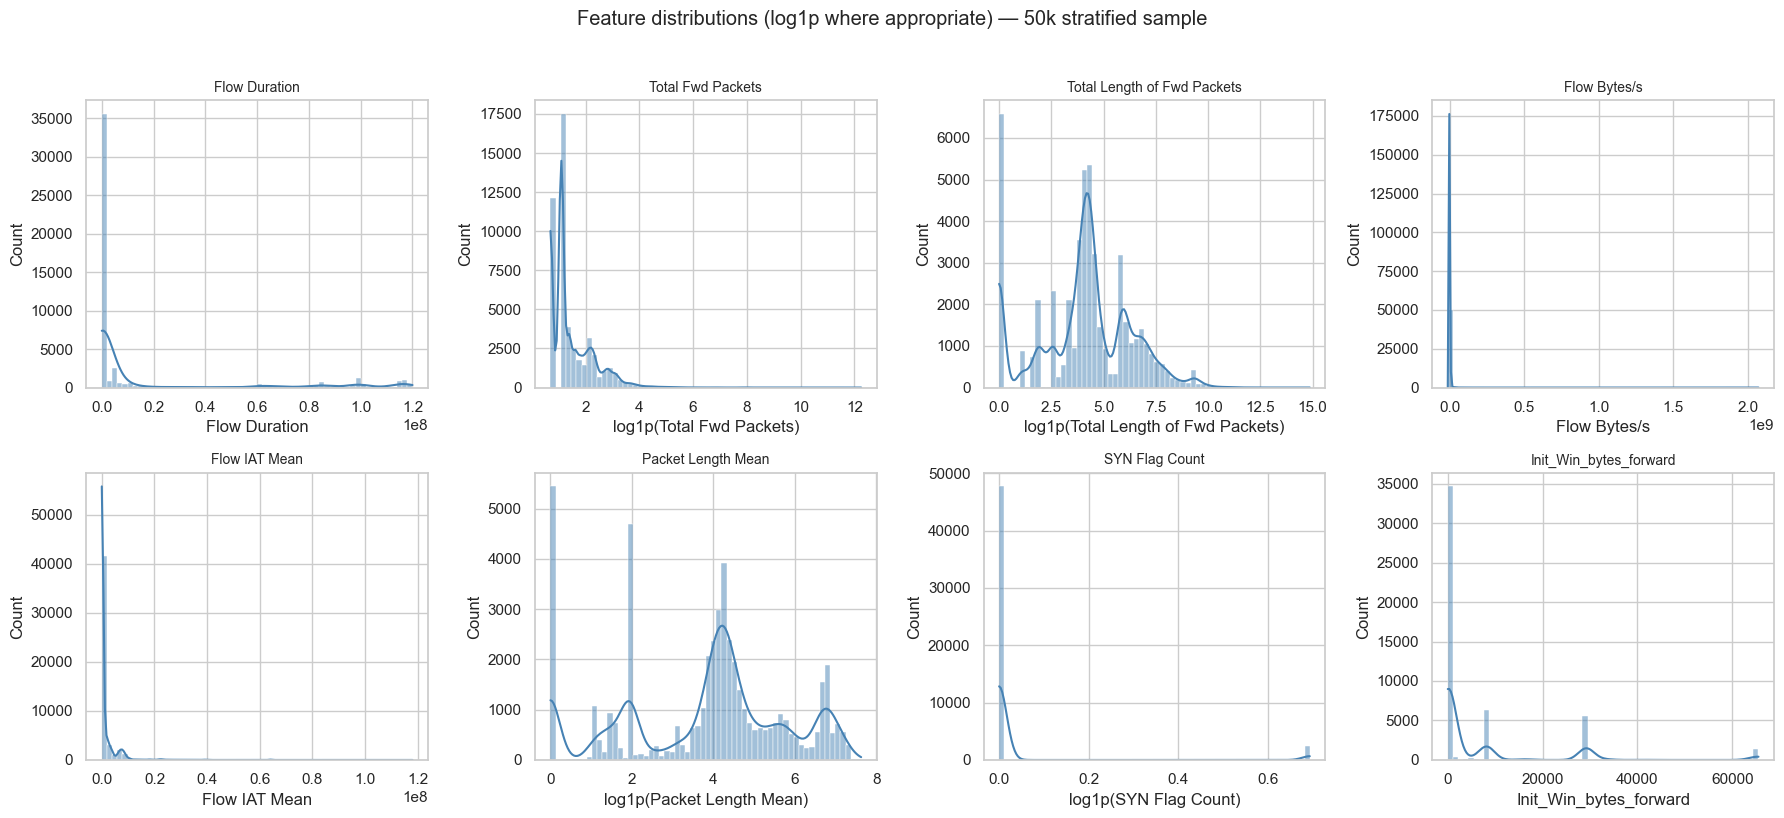

In [19]:
# Histograms + KDE για 8 αντιπροσωπευτικά features.
feat_subset = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Length of Fwd Packets',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Packet Length Mean',
    'SYN Flag Count',
    'Init_Win_bytes_forward',
]
feat_subset = [c for c in feat_subset if c in sample_df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, feat_subset):
    data = sample_df[col].replace([np.inf, -np.inf], np.nan).dropna()
    # Μετατόπιση για αποφυγή log(0)· αν η στήλη έχει αρνητικές τιμές, παρακάμπτουμε το log.
    if data.min() >= 0 and data.max() > 0:
        log_data = np.log1p(data)
        sns.histplot(log_data, kde=True, ax=ax, color='steelblue', bins=60)
        ax.set_xlabel(f'log1p({col})')
    else:
        sns.histplot(data, kde=True, ax=ax, color='steelblue', bins=60)
        ax.set_xlabel(col)
    ax.set_title(col, fontsize=10)
plt.suptitle('Feature distributions (log1p where appropriate) - 50k stratified sample', y=1.02)
plt.tight_layout()
save_figure(fig, 'q1_histograms_kde.png')
plt.show()


**Πώς διαβάζονται αυτά τα plots.** Οι περισσότερες flow-level στήλες είναι *right-skewed* και *heavy-tailed* - το KDE στην αρχική κλίμακα θα ήταν μία κορυφή στο 0 με λεπτή ουρά. Ο μετασχηματισμός `log1p` (log(1+x), ασφαλής για μηδενικά) συμπιέζει την ουρά και αποκαλύπτει τη δομή. Αρκετά features φαίνονται καθαρά **multi-modal** (π.χ. `Init_Win_bytes_forward`) - πολλαπλές κορυφές σημαίνει πολλαπλά υποκείμενα regime, που είναι συχνά εκεί όπου χωρίζεται attack από benign traffic.

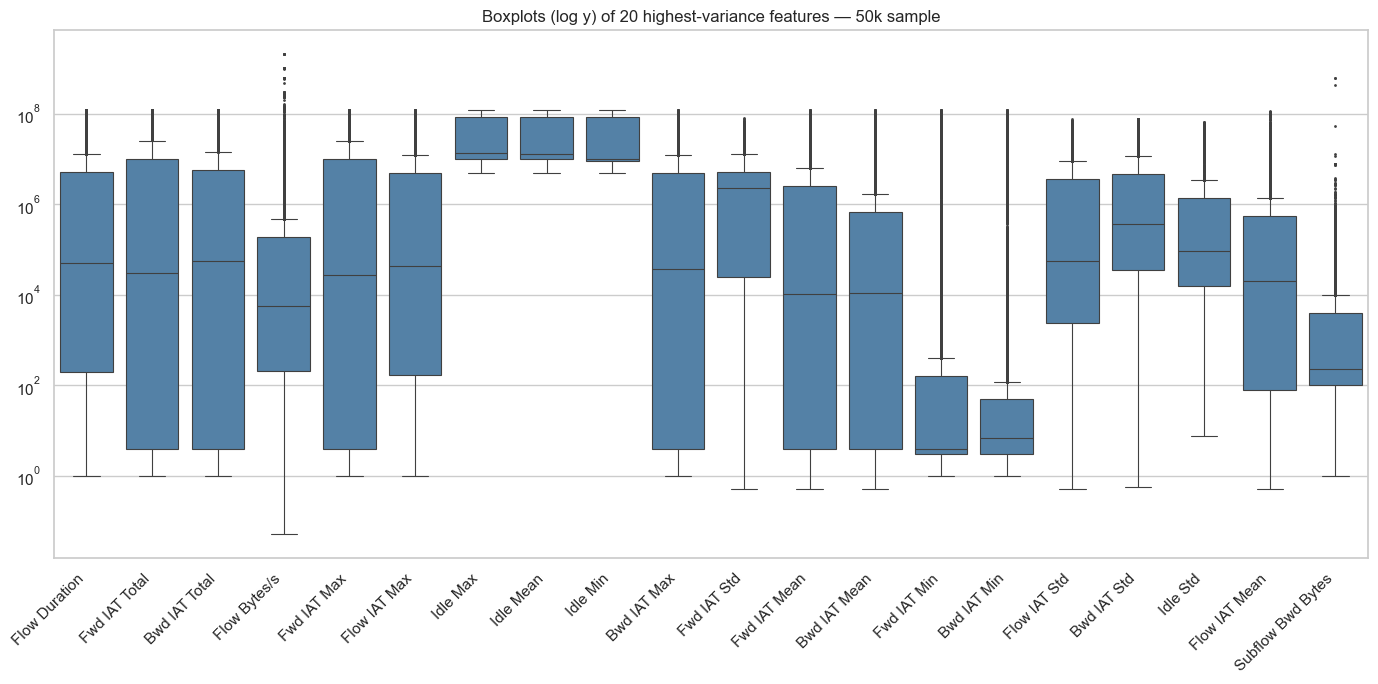

In [20]:
# Boxplots - log scale στον y. Κατατάσσουμε features κατά variance ώστε να
# εμφανιστούν οι πιο ενημερωτικές.
plot_cols = (
    sample_df.select_dtypes(include=np.number)
             .var()
             .sort_values(ascending=False)
             .head(20)
             .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))
positive_only = sample_df[plot_cols].copy()
positive_only = positive_only.where(positive_only > 0)
sns.boxplot(data=positive_only, ax=ax, showfliers=True, fliersize=1, linewidth=0.8, color='steelblue')
ax.set_yscale('log')
ax.set_title('Boxplots (log y) of 20 highest-variance features - 50k sample')
ax.tick_params(axis='x', rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_horizontalalignment('right')
plt.tight_layout()
save_figure(fig, 'q1_boxplots_top20.png')
plt.show()


**Πώς διαβάζεται ένα boxplot.**

- Το **κουτί** εκτείνεται από το Q1 (25th percentile) έως το Q3 (75th percentile) - το 50% των δεδομένων βρίσκεται μέσα του.
- Η **γραμμή μέσα στο κουτί** είναι το median (50th percentile).
- Τα **whiskers** επεκτείνονται μέχρι το πιο ακραίο σημείο εντός 1.5 × IQR από το κουτί.
- Οι **τελείες πέρα από τα whiskers** είναι outliers (κατά τη σύμβαση 1.5·IQR).

Το πολύ μακρύ άνω whisker με σύννεφο outliers πάνω από αυτό - ακριβώς αυτό που βλέπουμε στις στήλες flow-duration και byte-length - είναι η οπτική υπογραφή του ακραίου skewness που ποσοτικοποιήσαμε στην §1.3.

## 1.6 Ανάλυση συσχέτισης (correlation)

Η **Pearson correlation** μετρά τη *γραμμική* σχέση μεταξύ δύο μεταβλητών, κανονικοποιημένη στο διάστημα [-1, +1].

- `r = +1` σημαίνει «όταν το X ανεβαίνει, το Y ανεβαίνει στην ίδια αναλογία» (τέλεια θετική γραμμική).
- `r = 0` σημαίνει καμία γραμμική σχέση (αλλά μπορεί να υπάρχει non-linear - η Pearson είναι τυφλή σε αυτό).
- `r = -1` σημαίνει τέλεια αντίστροφη γραμμική.

**Γιατί μας ενδιαφέρει:** ένα ζεύγος features με |r| ≈ 1 φέρει την ίδια πληροφορία. Η διατήρηση και των δύο σπαταλάει στήλες, εισάγει bias σε distance-based αλγόριθμους (K-Means, KNN, DBSCAN), και αποσταθεροποιεί τους συντελεστές της Logistic Regression. Αυτό το φαινόμενο λέγεται **multicollinearity**.

In [21]:
# Πλήρες numeric correlation matrix (εξαιρώντας label και provenance helper).
# Οι zero-variance στήλες κάνουν τον παρονομαστή της Pearson να είναι 0, παράγοντας
# NaN και ένα ακίνδυνο RuntimeWarning. Σιγάζουμε το warning - τα NaN κελιά είναι
# η σωστή απάντηση και θα διαγράψουμε αυτές τις constant στήλες ρητά στην §1.7.
import warnings

num_df = df.drop(columns=['Label', '__source_file']).select_dtypes(include=np.number)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    corr = num_df.corr(method='pearson')
print(f'Correlation matrix shape: {corr.shape}')
print(f'Columns producing NaN correlations (zero variance): {corr.isna().all().sum()}')


Correlation matrix shape: (77, 77)
Columns producing NaN correlations (zero variance): 8


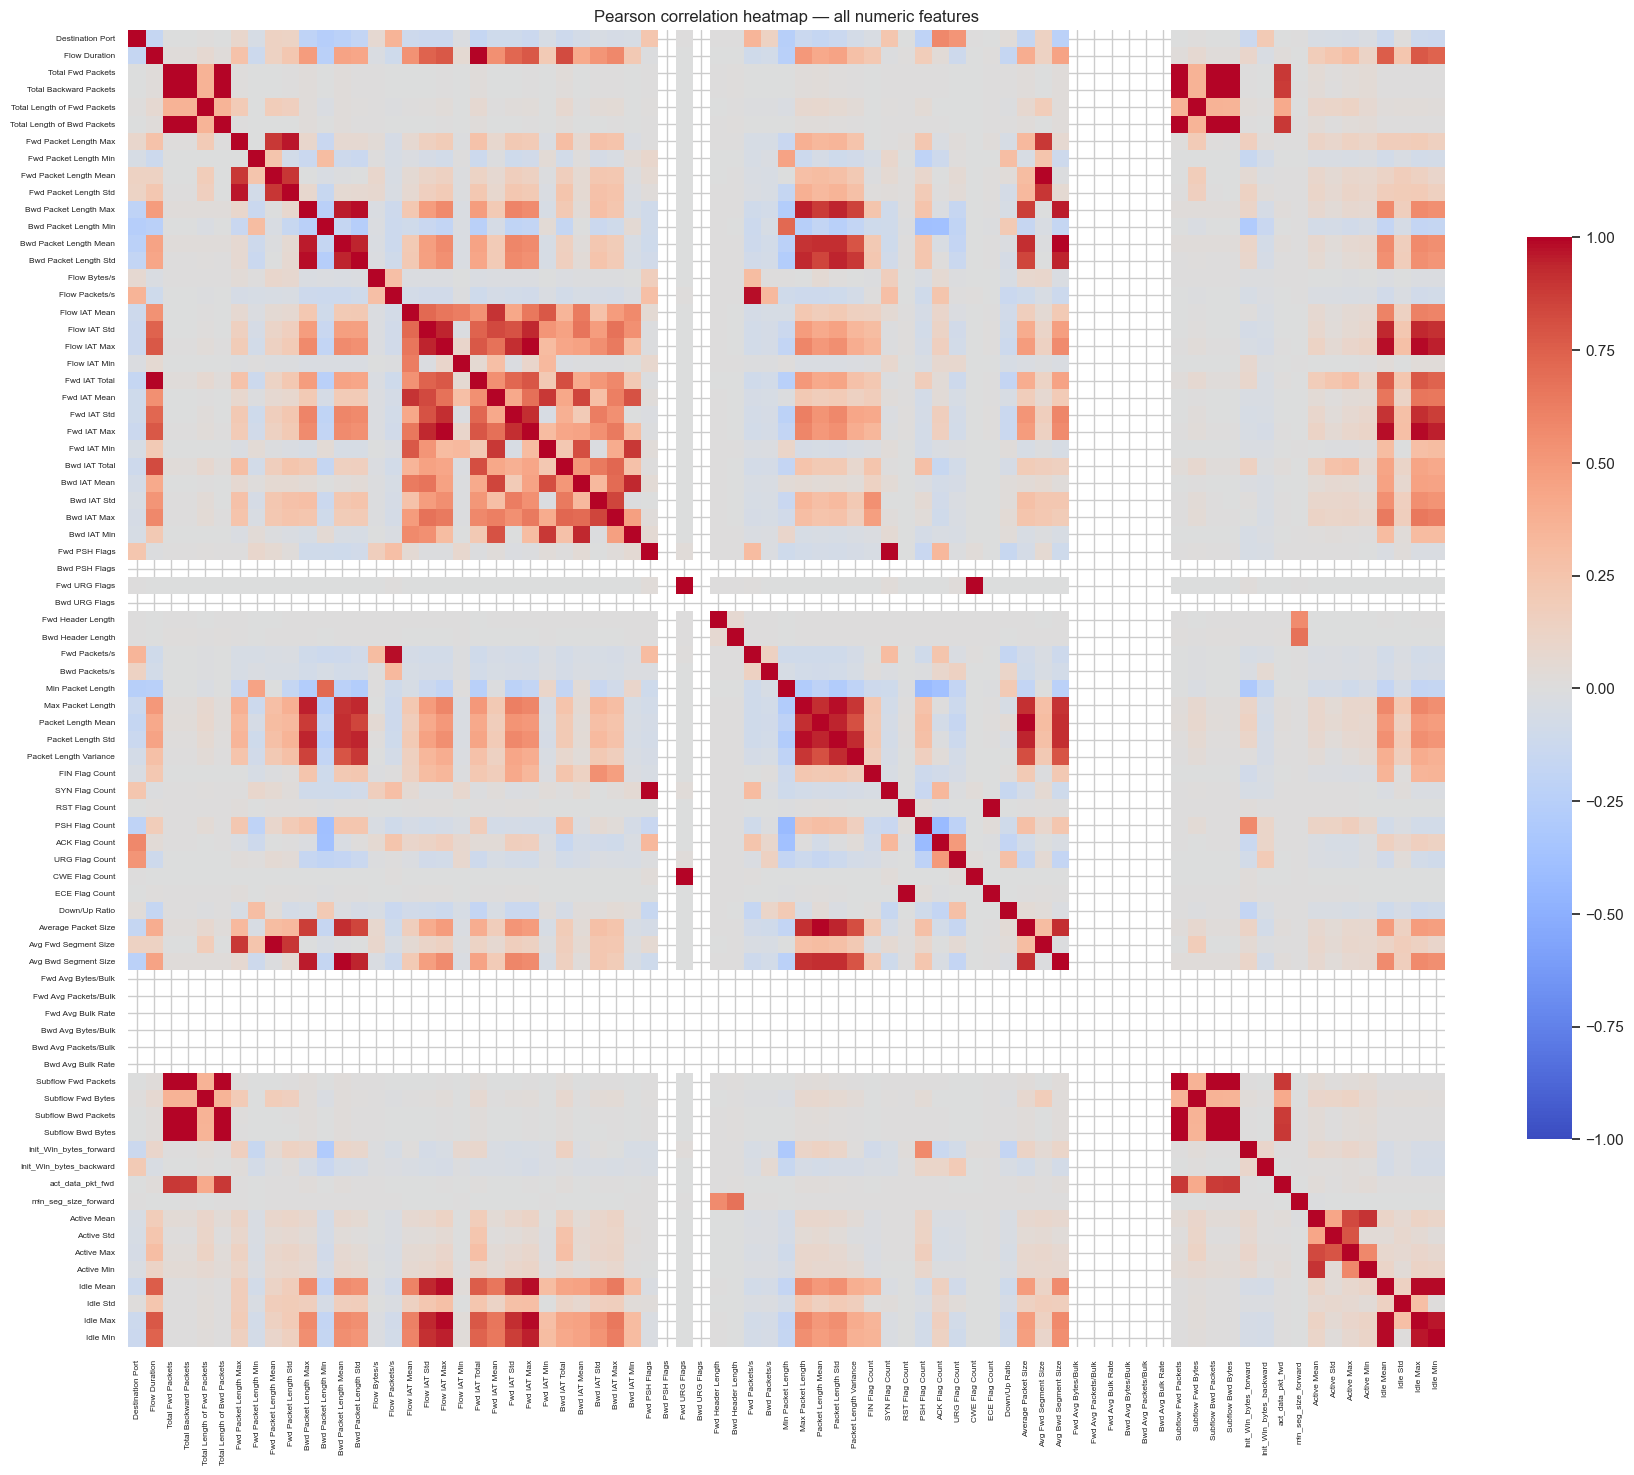

In [22]:
# Πλήρες 77×77 heatmap - μικρές γραμματοσειρές αλλά ορατή δομή clusters.
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, cbar_kws={'shrink': 0.6},
    xticklabels=True, yticklabels=True,
)
ax.set_title('Pearson correlation heatmap - all numeric features')
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
save_figure(fig, 'q1_correlation_heatmap.png')
plt.show()


Η φωτεινή διαγώνιος είναι self-correlation (r = 1). Τα off-diagonal *blocks* έντονου κόκκινου είναι clusters από πολύ-συσχετισμένα features - π.χ. `Subflow Fwd Bytes` vs. `Total Length of Fwd Packets` (στην ουσία το ίδιο πράγμα μετρημένο αλλιώς), ή η οικογένεια `Fwd IAT` στηλών. Αυτά τα clusters είναι ακριβώς αυτά που θα στοχεύσουμε στην §1.7.

In [23]:
top_pairs = top_correlated_pairs(corr, top_n=15)
save_results(top_pairs, 'q1_top_correlated_pairs.csv')
top_pairs


,feature_a,feature_b,corr,abs_corr
0,Bwd Packet Length Mean,Avg Bwd Segment Size,1.0000,1.0000
1,Total Fwd Packets,Subflow Fwd Packets,1.0000,1.0000
2,Total Backward Packets,Subflow Bwd Packets,1.0000,1.0000
3,Fwd URG Flags,CWE Flag Count,1.0000,1.0000
4,Fwd Packet Length Mean,Avg Fwd Segment Size,1.0000,1.0000
5,Fwd PSH Flags,SYN Flag Count,1.0000,1.0000
6,Total Length of Bwd Packets,Subflow Bwd Bytes,1.0000,1.0000
7,Total Length of Fwd Packets,Subflow Fwd Bytes,1.0000,1.0000
8,Total Backward Packets,Subflow Fwd Packets,0.9991,0.9991
9,Subflow Fwd Packets,Subflow Bwd Packets,0.9991,0.9991


In [24]:
# Correlation με το Label. Χρειαζόμαστε numeric target για Pearson, οπότε
# κάνουμε πρώτα label-encoding.
# Το pd.DataFrame.corrwith είναι πιο καθαρό από apply+np.corrcoef: επιστρέφει
# σιωπηλά NaN για zero-variance στήλες αντί να σηκώσει runtime warning.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = pd.Series(le.fit_transform(df['Label']), index=df.index, name='Label_enc')
corr_with_label = num_df.corrwith(y_enc).sort_values(key=abs, ascending=False)
corr_label_df = corr_with_label.to_frame('corr_with_label')
save_results(corr_label_df.reset_index().rename(columns={'index': 'feature'}), 'q1_corr_with_label.csv')
corr_label_df.head(15)


,corr_with_label
Fwd IAT Std,0.3014
Idle Mean,0.2805
Bwd Packet Length Std,0.2802
Idle Max,0.2794
Idle Min,0.2780
Fwd IAT Max,0.2764
Flow IAT Max,0.2759
Bwd Packet Length Max,0.2741
Avg Bwd Segment Size,0.2648
Bwd Packet Length Mean,0.2648


**Επιφύλαξη για το correlation-with-label.** Το `Label` είναι nominal μεταβλητή με 15 κατηγορίες· το label-encoding επιβάλλει αυθαίρετη διάταξη (`BENIGN`=0, `Bot`=1, ...). Μια υψηλή Pearson correlation με το `y_enc` είναι επομένως *ενδεικτική*, όχι πραγματικό supervised feature-importance score. Για μια πιο ορθή εκδοχή θα χρησιμοποιούσαμε **mutual information** ή tree-based feature importance - θα το ξαναδούμε στο Q2. Προς το παρόν, αυτή η οπτική μας βοηθάει να εντοπίσουμε στήλες που συστηματικά μεταβάλλονται με τον τύπο επίθεσης έναντι στηλών που φαίνονται ίδιες παντού.

## 1.7 Feature selection

**Κριτήρια αφαίρεσης - όλα τεκμηριωμένα από την παραπάνω ανάλυση.**

| Κανόνας | Αιτιολογία |
|---|---|
| **Bookkeeping columns** (`__source_file`) | βοηθητική για debugging· δεν είναι πραγματικό feature |
| **Zero variance** | η στήλη είναι constant· δεν μεταφέρει πληροφορία |
| **Near-zero variance** (`var < 1e-6`) | σχεδόν constant· οι περισσότερες `Bulk` στήλες πέφτουν εδώ |
| **High correlation** (`\|r\| > 0.95`) | multicollinear near-duplicates - κρατάμε ένα ανά cluster |

Χτίζουμε ένα *removal ledger* ώστε κάθε διαγεγραμμένη στήλη να έχει τεκμηριωμένο λόγο.

In [25]:
removal_rows: list[dict] = []

# 1) Διαγραφή της bookkeeping στήλης.
if '__source_file' in df.columns:
    removal_rows.append({'column': '__source_file', 'reason': 'bookkeeping / non-feature helper column'})

# 2) Zero-variance columns.
zero_var = find_low_variance_features(num_df, threshold=0.0)
for col in zero_var:
    removal_rows.append({'column': col, 'reason': 'zero variance (constant)'})

# 3) Near-zero-variance columns (μετά την αφαίρεση του zero-var set ώστε να μη διπλοϋπολογίσουμε).
remaining_numeric = num_df.drop(columns=zero_var, errors='ignore')
near_zero_var = [c for c in find_low_variance_features(remaining_numeric, threshold=1e-6) if c not in zero_var]
for col in near_zero_var:
    removal_rows.append({'column': col, 'reason': 'near-zero variance (var < 1e-6)'})

# 4) Highly correlated columns.
remaining_after_var = num_df.drop(columns=list(zero_var) + list(near_zero_var), errors='ignore')
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    corr_remaining = remaining_after_var.corr(method='pearson')
high_corr = find_highly_correlated_features(corr_remaining, threshold=0.95)
for col in high_corr:
    removal_rows.append({'column': col, 'reason': 'highly correlated (|r|>0.95) with another kept feature'})

removal_df = pd.DataFrame(removal_rows).drop_duplicates('column').reset_index(drop=True)
save_results(removal_df, 'q1_removed_features.csv')
print(f'Total columns removed: {len(removal_df)}')
removal_df


Total columns removed: 31


,column,reason
0,__source_file,bookkeeping / non-feature helper column
1,Bwd PSH Flags,zero variance (constant)
2,Bwd URG Flags,zero variance (constant)
3,Fwd Avg Bytes/Bulk,zero variance (constant)
4,Fwd Avg Packets/Bulk,zero variance (constant)
5,Fwd Avg Bulk Rate,zero variance (constant)
6,Bwd Avg Bytes/Bulk,zero variance (constant)
7,Bwd Avg Packets/Bulk,zero variance (constant)
8,Bwd Avg Bulk Rate,zero variance (constant)
9,Average Packet Size,highly correlated (|r|>0.95) with another kept...


In [26]:
# Εφαρμογή της αφαίρεσης και αποθήκευση του τελικού feature-selected dataset.
cols_to_drop = [c for c in removal_df['column'].tolist() if c in df.columns]
df_clean = df.drop(columns=cols_to_drop).reset_index(drop=True)

print(f'Final shape    : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Columns kept   : {df_clean.shape[1] - 1} features + 1 Label')
print('Label still present:', 'Label' in df_clean.columns)

final_features = pd.DataFrame({'column': df_clean.columns})
save_results(final_features, 'q1_final_feature_list.csv')
df_clean.head()


Final shape    : 2,572,640 rows × 48 columns


Columns kept   : 47 features + 1 Label
Label still present: True


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Std,Label
0,54865,3,2,12,6,6,6.0000,0,0,4000000.0000,666666.6667,3.0000,0.0000,3,3,3.0000,0.0000,3,0,0.0000,0.0000,0,0,0,0,40,0,0.0000,6,6,6.0000,0.0000,0,0,0,1,0,0,33,-1,1,20,0.0000,0.0000,0,0,0.0000,BENIGN
1,55054,109,1,6,6,6,6.0000,6,6,110091.7431,18348.6238,109.0000,0.0000,109,109,0.0000,0.0000,0,0,0.0000,0.0000,0,0,0,0,20,20,9174.3119,6,6,6.0000,0.0000,0,0,0,1,1,1,29,256,0,20,0.0000,0.0000,0,0,0.0000,BENIGN
2,55055,52,1,6,6,6,6.0000,6,6,230769.2308,38461.5385,52.0000,0.0000,52,52,0.0000,0.0000,0,0,0.0000,0.0000,0,0,0,0,20,20,19230.7692,6,6,6.0000,0.0000,0,0,0,1,1,1,29,256,0,20,0.0000,0.0000,0,0,0.0000,BENIGN
3,46236,34,1,6,6,6,6.0000,6,6,352941.1765,58823.5294,34.0000,0.0000,34,34,0.0000,0.0000,0,0,0.0000,0.0000,0,0,0,0,20,20,29411.7647,6,6,6.0000,0.0000,0,0,0,1,1,1,31,329,0,20,0.0000,0.0000,0,0,0.0000,BENIGN
4,54863,3,2,12,6,6,6.0000,0,0,4000000.0000,666666.6667,3.0000,0.0000,3,3,3.0000,0.0000,3,0,0.0000,0.0000,0,0,0,0,40,0,0.0000,6,6,6.0000,0.0000,0,0,0,1,0,0,32,-1,1,20,0.0000,0.0000,0,0,0.0000,BENIGN


In [27]:
# Αποθήκευση σε Parquet για Q2 και Q3.
path = save_clean_cached(df_clean)
size_mb = path.stat().st_size / 1e6
print(f'Cleaned dataset written to {path}')
print(f'File size: {size_mb:.1f} MB (Parquet is columnar + compressed, so this is much smaller than raw CSV)')


Cleaned dataset written to D:\Documents\GitHub\network-intrusion-detection-ml\data\cic_ids_2017_clean.parquet
File size: 221.9 MB (Parquet is columnar + compressed, so this is much smaller than raw CSV)


## 1.8 Σύνοψη βασικών ευρημάτων

### Dataset μετά τον καθαρισμό
- Οι γραμμές και στήλες αποθηκεύονται στο κελί παραπάνω· οι αριθμοί τυπώνονται inline.
- Όλα τα Infs αντικαταστάθηκαν με NaN, όλες οι γραμμές που περιείχαν NaN διαγράφηκαν (<0.1% απώλεια), όλα τα duplicates αφαιρέθηκαν.

### Ζητήματα ποιότητας δεδομένων που εντοπίστηκαν και διορθώθηκαν
| Πρόβλημα | Διόρθωση |
|---|---|
| Leading whitespace σε κάθε όνομα στήλης | stripped στον loader |
| `Fwd Header Length.1` είναι 100% διπλότυπο του `Fwd Header Length` | dropped |
| Αλλοιωμένα bytes (U+FFFD) στα Web Attack labels | normalized σε printable ASCII |
| Inf values στα `Flow Bytes/s`, `Flow Packets/s` (διαίρεση με 0 duration) | αντικατάσταση με NaN, μετά row-drop |
| Ακριβή διπλότυπες γραμμές | αφαιρέθηκαν πριν το split |

### Πιο σημαντικά patterns
- **Σοβαρό class imbalance** - BENIGN ≈ 80% των δεδομένων· το Heartbleed έχει μόλις 11 γραμμές σε 2.8M. Αυτό θα καθορίσει κάθε απόφαση του Q2 (επιλογή metrics, class-weighting, stratified split).
- **Βαρύ right-skewness και τεράστιο kurtosis** σε στήλες bytes/duration/rate - τα log-scale plots είναι υποχρεωτικά· ο `RobustScaler` είναι υποψήφιος για το Q2.
- **Clusters από redundant features** - `Total Length of Fwd Packets` ↔ `Subflow Fwd Bytes`, `Avg Fwd Segment Size` ↔ `Fwd Packet Length Mean` κ.λπ. Αυτά είναι near-duplicates και διαγράψαμε ένα από κάθε cluster.
- **Οι Bulk-rate στήλες είναι ~0 σχεδόν σε κάθε flow**, πιάνονται από το zero-variance φίλτρο.

### Features που αφαιρέθηκαν και γιατί
Δες `outputs/results/q1_removed_features.csv` για το πλήρες ledger.

### Τι θα παραλάβουν τα Q2 και Q3
Ένα μόνο αρχείο Parquet `data/cic_ids_2017_clean.parquet` που περιέχει τις καθαρές, feature-selected γραμμές μαζί με τη στήλη `Label`. Τα Q2 και Q3 το φορτώνουν με `utils.helpers.load_clean_cached()` σε <2 δευτερόλεπτα.